# 02 — Shallow weak learners

This rank-one experiment isolates the effect of model accumulation. Every regression tree has depth two. FSNM retains an additive expansion of trees, whereas ACE replaces each transformation with the latest tree.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import ParameterGrid

from ace import fit_ace
from fsnm import empirical_loss, fit_fsnm


def basis(values):
    return np.sqrt(2) * np.cos(np.pi * np.asarray(values))


def kappa_exact(x_values, y_values):
    return 1 + SIGMA * np.outer(basis(x_values), basis(y_values))


def sample_joint(size, seed):
    rng = np.random.default_rng(seed)
    upper_bound = 1 + 2 * SIGMA
    x_parts = []
    y_parts = []
    n_accepted = 0

    while n_accepted < size:
        x = rng.uniform(-1, 1, size)
        y = rng.uniform(-1, 1, size)
        density_ratio = 1 + SIGMA * basis(x) * basis(y)
        accepted = rng.uniform(size=size) < density_ratio / upper_bound
        x_parts.append(x[accepted])
        y_parts.append(y[accepted])
        n_accepted += accepted.sum()

    return np.concatenate(x_parts)[:size], np.concatenate(y_parts)[:size]

We use

$$\kappa(x,y)=1+\sigma e(x)e(y),\qquad e(t)=\sqrt{2}\cos(\pi t),$$

with $\sigma=0.4$. A single depth-two regression tree gives only a four-leaf step function, while the FSNM expansion can accumulate several such weak learners to approximate the smooth profile.

In [2]:
SIGMA = 0.4
N_TRAIN = 5_000
N_VALIDATION = 2_000
MAX_DEPTH = 2
SEED = 0

x_train, y_train = sample_joint(N_TRAIN, seed=12)
x_validation, y_validation = sample_joint(N_VALIDATION, seed=99)

In [3]:
fsnm_grid = {
    "n_iterations": [10, 20, 40, 80],
    "step_size": [0.05, 0.1, 0.2],
    "min_samples_leaf": [50, 100, 300],
}
ace_grid = {
    "n_iterations": [5, 10, 20, 40, 80],
    "min_samples_leaf": [50, 100, 300],
}

fsnm_results = []
for parameters in ParameterGrid(fsnm_grid):
    candidate_phi, candidate_psi, candidate_values, _ = fit_fsnm(
        x_train,
        y_train,
        rank=1,
        max_depth=MAX_DEPTH,
        seed=SEED,
        **parameters,
    )
    scale = np.sqrt(candidate_values)
    phi_validation = candidate_phi.predict(x_validation[:, None]) * scale
    psi_validation = candidate_psi.predict(y_validation[:, None]) * scale
    fsnm_results.append(
        {**parameters, "validation_loss": float(empirical_loss(phi_validation, psi_validation))}
    )

ace_results = []
for parameters in ParameterGrid(ace_grid):
    candidate_phi, candidate_psi, candidate_value, _ = fit_ace(
        x_train,
        y_train,
        max_depth=MAX_DEPTH,
        seed=SEED,
        **parameters,
    )
    scale = np.sqrt(candidate_value)
    phi_validation = candidate_phi.predict(x_validation[:, None]) * scale
    psi_validation = candidate_psi.predict(y_validation[:, None]) * scale
    ace_results.append(
        {**parameters, "validation_loss": float(empirical_loss(phi_validation, psi_validation))}
    )

fsnm_results.sort(key=lambda result: result["validation_loss"])
ace_results.sort(key=lambda result: result["validation_loss"])
fsnm_parameters = {name: fsnm_results[0][name] for name in fsnm_grid}
ace_parameters = {name: ace_results[0][name] for name in ace_grid}

print(f"FSNM evaluated combinations: {len(fsnm_results)}")
print(f"FSNM best hyperparameters: {fsnm_parameters}")
print(f"FSNM validation loss: {fsnm_results[0]['validation_loss']:.4f}")
print(f"ACE evaluated combinations: {len(ace_results)}")
print(f"ACE best hyperparameters: {ace_parameters}")
print(f"ACE validation loss: {ace_results[0]['validation_loss']:.4f}")

FSNM evaluated combinations: 36
FSNM best hyperparameters: {'n_iterations': 40, 'step_size': 0.05, 'min_samples_leaf': 50}
FSNM validation loss: -0.1148
ACE evaluated combinations: 15
ACE best hyperparameters: {'n_iterations': 5, 'min_samples_leaf': 100}
ACE validation loss: -0.1147


In [4]:
fsnm_times = []
for _ in range(3):
    start = perf_counter()
    phi_fsnm, psi_fsnm, values_fsnm, _ = fit_fsnm(
        x_train,
        y_train,
        rank=1,
        max_depth=MAX_DEPTH,
        seed=SEED,
        **fsnm_parameters,
    )
    fsnm_times.append(perf_counter() - start)
time_fsnm = np.median(fsnm_times)

ace_times = []
for _ in range(3):
    start = perf_counter()
    phi_ace, psi_ace, value_ace, _ = fit_ace(
        x_train,
        y_train,
        max_depth=MAX_DEPTH,
        seed=SEED,
        **ace_parameters,
    )
    ace_times.append(perf_counter() - start)
time_ace = np.median(ace_times)

grid = np.linspace(-1, 1, 160)
kappa_true = kappa_exact(grid, grid)
kappa_fsnm = 1 + (
    phi_fsnm.predict(grid[:, None]) * values_fsnm
) @ psi_fsnm.predict(grid[:, None]).T
kappa_ace = 1 + value_ace * np.outer(
    phi_ace.predict(grid[:, None]), psi_ace.predict(grid[:, None])
)

rmse_fsnm = np.sqrt(np.mean((kappa_fsnm - kappa_true) ** 2))
rmse_ace = np.sqrt(np.mean((kappa_ace - kappa_true) ** 2))
print(f"True singular value: {SIGMA:.4f}")
print(f"FSNM singular value: {values_fsnm[0]:.4f}")
print(f"ACE singular value:  {value_ace:.4f}")
print(f"FSNM grid RMSE:       {rmse_fsnm:.4f}")
print(f"ACE grid RMSE:        {rmse_ace:.4f}")
print(f"FSNM training time:   {time_fsnm:.4f} s")
print(f"ACE training time:    {time_ace:.4f} s")

True singular value: 0.4000
FSNM singular value: 0.3458
ACE singular value:  0.3267
FSNM grid RMSE:       0.2223
ACE grid RMSE:        0.2556
FSNM training time:   1.5723 s
ACE training time:    0.0224 s


Figure saved to: /home/thiago/Projects/paper-fsnm/code/fsnm/figures/02_shallow_weak_learners.png


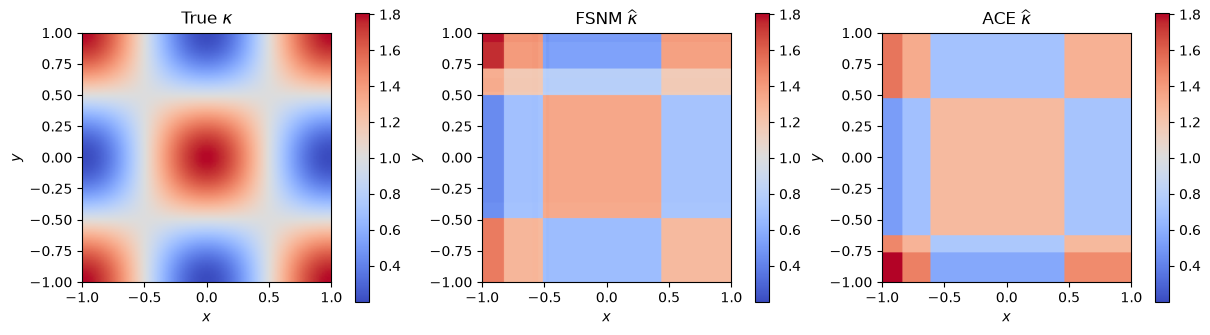

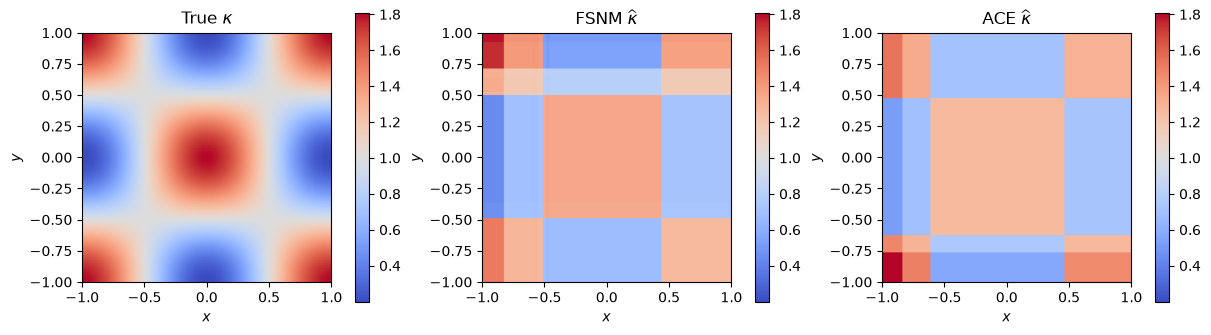

In [5]:
value_limits = (
    min(kappa_true.min(), kappa_fsnm.min(), kappa_ace.min()),
    max(kappa_true.max(), kappa_fsnm.max(), kappa_ace.max()),
)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
for axis, (values, title) in zip(
    axes,
    [
        (kappa_true, r"True $\kappa$"),
        (kappa_fsnm, r"FSNM $\widehat\kappa$"),
        (kappa_ace, r"ACE $\widehat\kappa$"),
    ],
):
    image = axis.imshow(
        values.T,
        origin="lower",
        extent=[-1, 1, -1, 1],
        cmap="coolwarm",
        vmin=value_limits[0],
        vmax=value_limits[1],
    )
    axis.set(title=title, xlabel="$x$", ylabel="$y$")
    fig.colorbar(image, ax=axis, shrink=0.82)

project_directory = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
figure_directory = project_directory / "figures"
figure_directory.mkdir(exist_ok=True)
figure_path = figure_directory / "02_shallow_weak_learners.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
print(f"Figure saved to: {figure_path}")
fig